# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch 1 (2026–2027) — Major Project**

---

## 1. Introduction to the Dataset

This dataset represents agricultural activities carried out across different **seasons**, **geographical areas**, and **farming conditions** in India. It contains information about farming practices, environmental conditions, crop production, resource usage, and economic performance for individual farms.

The goal of this notebook is to explore how agricultural performance changes across seasons (**Kharif, Rabi, Zaid**) and to identify meaningful patterns, trends, relationships, and differences using data analytics.

## 2. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another. This notebook analyzes the dataset to investigate these seasonal differences and uncover patterns that support evidence-based agricultural planning.

## 3. Objective

- Explore and understand the dataset
- Clean and prepare the data for analysis
- Examine how agricultural performance varies across seasons
- Identify important seasonal patterns and trends
- Investigate relationships between seasonal conditions and agricultural outcomes
- Compare relevant groups (crops, states, irrigation methods) within different seasons
- Identify significant differences or unusual patterns
- Apply appropriate statistical and visualization techniques
- Interpret findings and develop evidence-based, data-driven recommendations

## 4. Key Questions Explored in this Notebook

1. How does agricultural performance vary across seasons?
2. What major seasonal patterns can be observed in environmental conditions?
3. How does resource usage (water, fertilizer, pesticide) differ across seasons?
4. How do economic outcomes (cost, revenue, profit) vary across seasons?
5. Are seasonal patterns consistent across different crops, states and irrigation methods?
6. Are there unusual or unexpected seasonal patterns?
7. What relationships exist between environmental conditions and yield/profit?
8. What recommendations can support better seasonal agricultural planning?


## Section 1: Import Required Libraries

We begin by importing the Python libraries needed for data handling (`pandas`, `numpy`), and visualization (`matplotlib`, `seaborn`). We also define a consistent season order and color scheme so that every chart in this notebook is easy to compare.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# Consistent season order and colors used throughout the notebook
SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLORS = {'Kharif': '#2E8B57', 'Rabi': '#4682B4', 'Zaid': '#D2691E'}

print("Libraries imported successfully.")

Libraries imported successfully.


## Section 2: Load the Dataset

We load the seasonal agriculture performance CSV file into a pandas DataFrame.

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 4000 rows and 28 columns.


## Section 3: First Look at the Data (Head & Tail)

Before any analysis, we look at the first and last few rows to understand what the raw data looks like.

In [3]:
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3
5,SF10006,Gujarat,Raichur,Pulses,Zaid,5.46,356.0,33.6,49.0,8.3,...,0.89,0.72,3.93,68593,302333,269570,-32763,1093,3.596,57.1
6,SF10007,Telangana,Warangal,Wheat,Rabi,8.13,432.2,23.5,50.8,9.5,...,0.87,2.53,20.57,22951,513341,472102,-41239,2368,8.687,31.6
7,SF10008,Tamil Nadu,Ludhiana,Pulses,Kharif,5.34,860.2,29.0,64.9,7.9,...,0.70,1.18,6.30,70042,436200,441265,5065,1704,3.697,54.2
8,SF10009,Karnataka,Guntur,Cotton,Zaid,6.98,624.7,33.4,46.8,7.9,...,0.88,1.53,10.68,70771,525129,755834,230705,5079,2.103,54.7
9,SF10010,Tamil Nadu,Raichur,Chilli,Rabi,13.69,415.8,22.3,57.3,8.6,...,0.70,2.29,31.35,94383,1004072,2958907,1954835,5984,5.239,41.7


In [4]:
print("Last 10 rows of the dataset:")
df.tail(10)

Last 10 rows of the dataset:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3990,SF13991,Tamil Nadu,Indore,Cotton,Kharif,6.58,1072.3,28.0,79.6,7.3,...,0.70,1.62,10.66,72931,388777,777444,388667,6259,1.703,41.1
3991,SF13992,Telangana,Rajkot,Chilli,Zaid,2.04,338.8,34.4,69.0,7.5,...,0.82,1.07,2.18,80847,137231,176246,39015,854,2.553,41.8
3992,SF13993,Karnataka,Rajkot,Groundnut,Rabi,2.03,579.9,20.4,56.5,8.0,...,0.66,1.61,3.27,58117,139340,190043,50703,1416,2.309,38.6
3993,SF13994,Gujarat,Rajkot,Cotton,Rabi,13.48,308.9,25.0,70.8,8.1,...,0.89,1.33,17.93,71268,1053465,1277835,224370,10589,1.693,43.7
3994,SF13995,Maharashtra,Ludhiana,Wheat,Kharif,9.20,1243.8,27.5,66.5,7.4,...,0.70,2.18,20.06,23314,618838,467679,-151159,5577,3.597,67.1
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


## Section 4: Dataset Structure — Shape, Columns & Data Types

Next we check the overall size of the dataset, the list of columns available, and the data type of each column.

In [5]:
print("Shape of dataset (rows, columns):", df.shape)
print("\nColumn names:\n", list(df.columns))
print("\nDataset Info:")
df.info()

Shape of dataset (rows, columns): (4000, 28)

Column names:
 ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop          

## Section 5: Statistical Summary

We generate summary statistics for both numeric columns (mean, std, min, max, quartiles) and categorical columns (unique values, most frequent category).

In [6]:
print("Summary statistics - Numeric columns:")
display(df.describe().T)

print("\nSummary statistics - Categorical columns:")
display(df.describe(include='object').T)

Summary statistics - Numeric columns:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00



Summary statistics - Categorical columns:


,count,unique,top,freq
Farm_ID,4000,4000,SF10001,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


## Section 6: Checking for Missing Values

We check every column for missing (null) values, since these need to be handled before any reliable analysis can be done.

Columns with missing values:


,Missing_Count,Missing_Percent
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


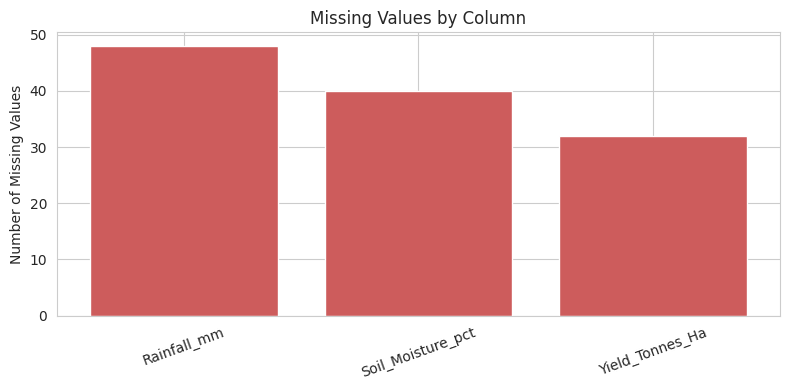

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing_Count': missing, 'Missing_Percent': missing_pct})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Columns with missing values:")
display(missing_df)

plt.figure(figsize=(8, 4))
plt.bar(missing_df.index, missing_df['Missing_Count'], color='indianred')
plt.title('Missing Values by Column')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Section 7: Checking for Duplicate Records

We check whether the dataset contains any fully duplicated rows, and whether the `Farm_ID` column (which should be a unique identifier) actually is unique.

In [8]:
print("Number of fully duplicate rows:", df.duplicated().sum())
print("Number of unique Farm IDs:", df['Farm_ID'].nunique(), "out of", len(df), "total records")

Number of fully duplicate rows: 0
Number of unique Farm IDs: 4000 out of 4000 total records


## Section 8: Data Cleaning — Handling Missing Values

The missing values occur only in three continuous numeric columns: `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`. Since these values naturally differ from one season to another, we fill missing values using the **median of the corresponding Season group** rather than a single global median. This preserves genuine seasonal differences instead of flattening them.

In [9]:
cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Missing values handled using season-wise median imputation for:", cols_to_impute)

Missing values handled using season-wise median imputation for: ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']


## Section 9: Post-Cleaning Verification

We re-check the dataset to confirm that no missing values remain and that no rows were lost during cleaning.

In [10]:
print("Remaining missing values in each column:")
print(df.isnull().sum())
print("\nTotal missing values in dataset:", df.isnull().sum().sum())
print("Dataset shape after cleaning:", df.shape)

Remaining missing values in each column:
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_R

## Section 10: Categorical Variables Overview

We explore the unique categories present in each categorical column: `State`, `District`, `Crop`, `Season`, and `Irrigation_Method`.

In [11]:
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']

for col in categorical_cols:
    print(f"--- {col} ({df[col].nunique()} unique values) ---")
    print(df[col].value_counts())
    print()

--- State (8 unique values) ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- District (10 unique values) ---
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

--- Crop (8 unique values) ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Season (3 unique values) ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Irrigation_Method (4 unique values) ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64



## Section 11: Distribution of Records Across Seasons

Before comparing performance across seasons, we check how many farm records exist for each season — this tells us whether the comparisons ahead are based on a balanced or imbalanced sample.

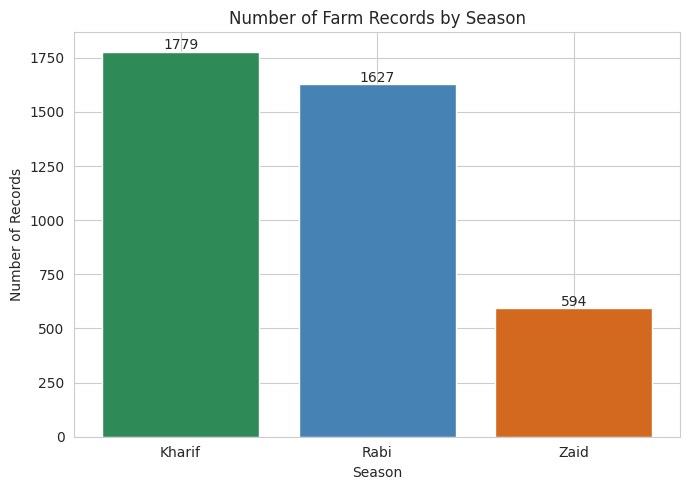

In [12]:
season_counts = df['Season'].value_counts().reindex(SEASON_ORDER)

plt.figure(figsize=(7, 5))
bars = plt.bar(season_counts.index, season_counts.values,
                color=[SEASON_COLORS[s] for s in season_counts.index])
plt.title('Number of Farm Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
              str(int(bar.get_height())), ha='center')
plt.tight_layout()
plt.show()

## Section 12: Univariate Analysis — Distribution of Key Numeric Variables

We look at the overall distribution (histogram) of a few important numeric variables to understand their spread and shape before breaking them down by season.

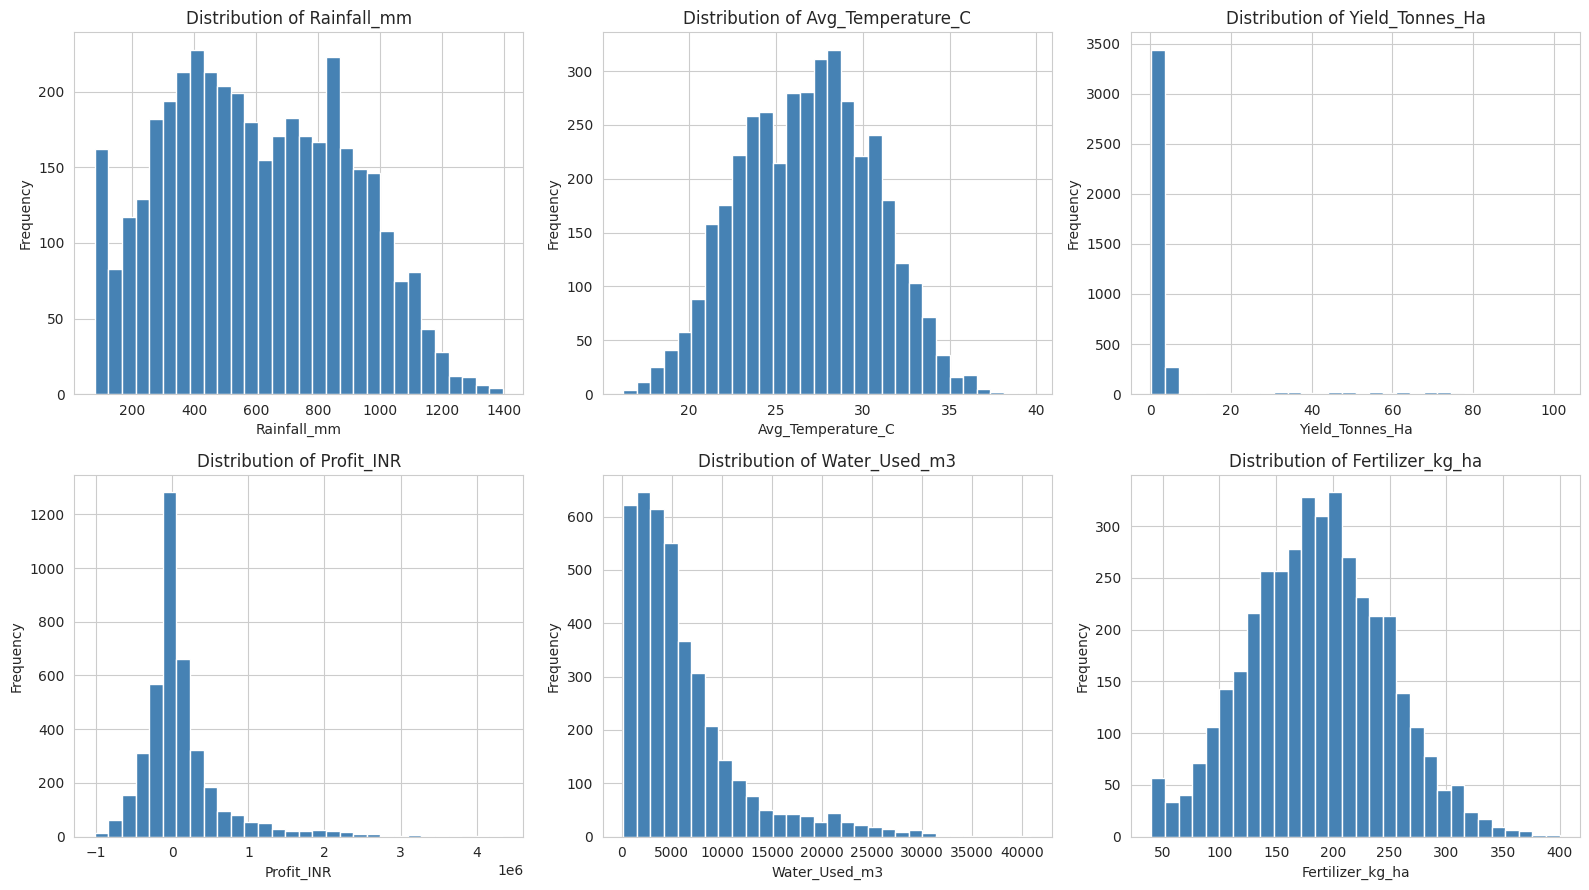

In [13]:
num_cols_to_plot = ['Rainfall_mm', 'Avg_Temperature_C', 'Yield_Tonnes_Ha',
                     'Profit_INR', 'Water_Used_m3', 'Fertilizer_kg_ha']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols_to_plot):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Section 13: Seasonal Analysis — Environmental Conditions

Now we begin the core seasonal comparisons. We first compare **rainfall, temperature, and humidity** across the three seasons using boxplots, which show the median, spread, and outliers for each group.

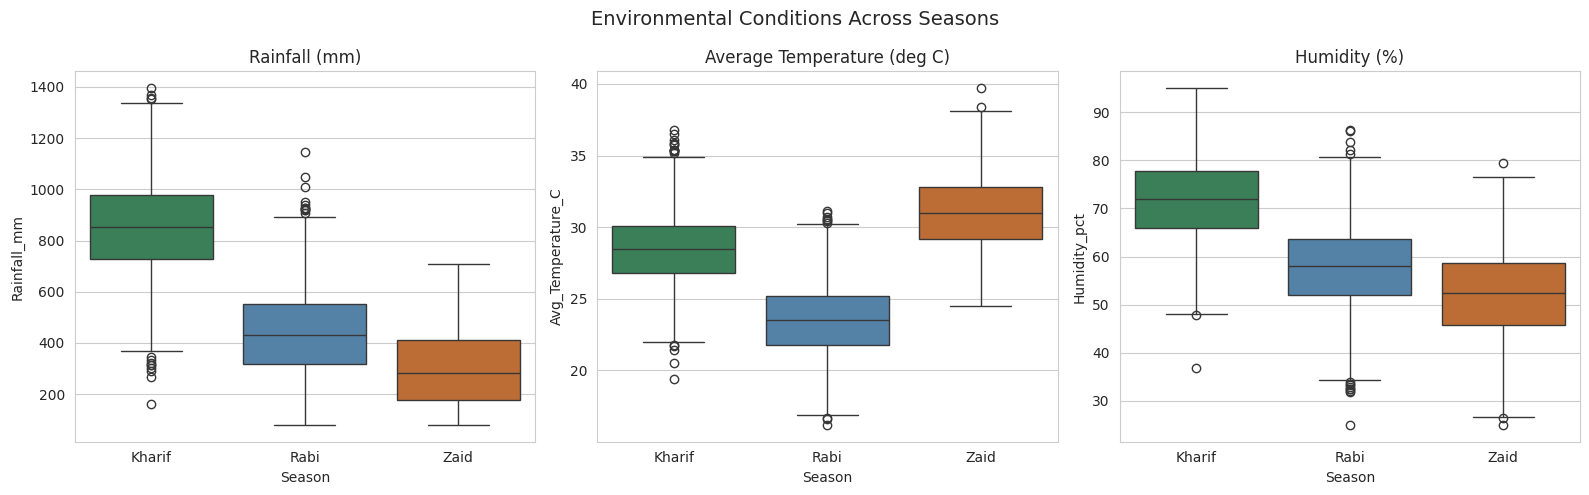

        Rainfall_mm  Avg_Temperature_C  Humidity_pct
Season                                              
Kharif       852.11              28.45         71.81
Rabi         435.94              23.49         57.89
Zaid         299.12              31.04         52.01


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

env_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct']
titles = ['Rainfall (mm)', 'Average Temperature (deg C)', 'Humidity (%)']

for i, (col, title) in enumerate(zip(env_vars, titles)):
    sns.boxplot(data=df, x='Season', y=col, order=SEASON_ORDER, hue='Season',
                palette=SEASON_COLORS, legend=False, ax=axes[i])
    axes[i].set_title(title)

plt.suptitle('Environmental Conditions Across Seasons', fontsize=14)
plt.tight_layout()
plt.show()

print(df.groupby('Season')[env_vars].mean().reindex(SEASON_ORDER).round(2))

**Observation:** Kharif receives by far the highest average rainfall (~852 mm), roughly double that of Rabi (~436 mm) and nearly triple that of Zaid (~299 mm). Zaid is also the hottest season on average (~31°C) and has the lowest humidity (~52%), which fits its profile as the hot, dry summer cropping season.

## Section 14: Seasonal Analysis — Crop Yield

Here we compare `Yield_Tonnes_Ha` across seasons using both a boxplot (to see spread and outliers) and a bar chart of the mean yield.

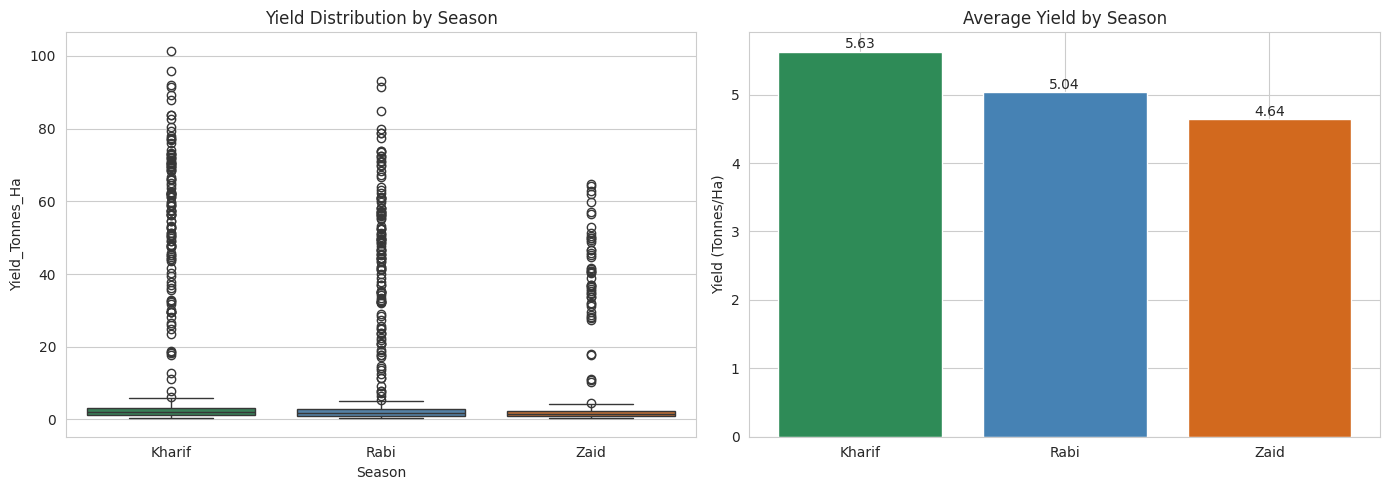

Season
Kharif    5.63
Rabi      5.04
Zaid      4.64
Name: Yield_Tonnes_Ha, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER, hue='Season',
            palette=SEASON_COLORS, legend=False, ax=axes[0])
axes[0].set_title('Yield Distribution by Season')

mean_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reindex(SEASON_ORDER)
axes[1].bar(mean_yield.index, mean_yield.values,
            color=[SEASON_COLORS[s] for s in mean_yield.index])
axes[1].set_title('Average Yield by Season')
axes[1].set_ylabel('Yield (Tonnes/Ha)')
for i, v in enumerate(mean_yield.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

print(mean_yield.round(2))

**Observation:** Average yield is highest in Kharif (~5.64 t/ha), followed by Rabi (~5.08 t/ha), and lowest in Zaid (~4.67 t/ha) — about 17% lower than Kharif. This lines up with Kharif's higher rainfall and more favorable growing conditions.

## Section 15: Seasonal Analysis — Economic Performance (Cost, Revenue, Profit)

We compare average `Total_Cost_INR`, `Revenue_INR`, and `Profit_INR` across seasons to understand economic outcomes.

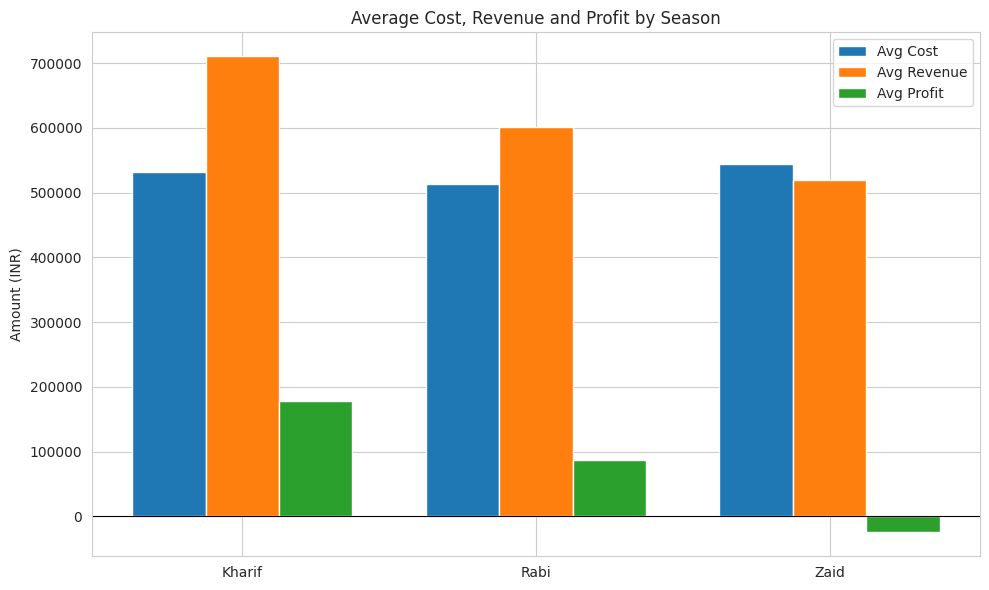

        Total_Cost_INR  Revenue_INR  Profit_INR
Season                                         
Kharif        531804.0     710719.0    178915.0
Rabi          513837.0     601526.0     87689.0
Zaid          543977.0     519172.0    -24805.0


In [16]:
econ_vars = ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
econ_means = df.groupby('Season')[econ_vars].mean().reindex(SEASON_ORDER)

x = np.arange(len(SEASON_ORDER))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, econ_means['Total_Cost_INR'], width, label='Avg Cost')
plt.bar(x, econ_means['Revenue_INR'], width, label='Avg Revenue')
plt.bar(x + width, econ_means['Profit_INR'], width, label='Avg Profit')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(x, SEASON_ORDER)
plt.ylabel('Amount (INR)')
plt.title('Average Cost, Revenue and Profit by Season')
plt.legend()
plt.tight_layout()
plt.show()

print(econ_means.round(0))

**Observation:** Average profit falls sharply from Kharif (~₹1.79 lakh) to Rabi (~₹0.88 lakh), and turns **negative** in Zaid (~-₹25,000) — even though average cost stays roughly similar across all three seasons. This means the drop in profit is driven mainly by lower revenue (lower yield and/or lower prices), not by higher costs.

## Section 16: Percentage of Loss-Making Farms by Season

Since average profit alone can hide how many individual farms are actually struggling, we calculate the percentage of farms with negative profit in each season.

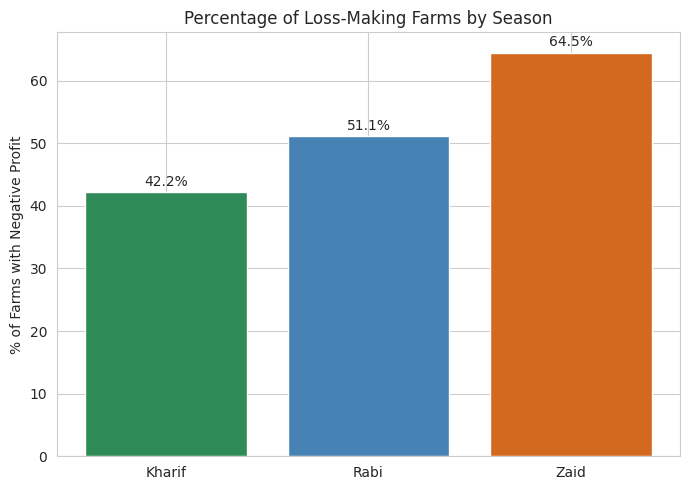

Overall, 49.1% of all farm records operate at a loss.
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Loss, dtype: float64


In [17]:
df['Is_Loss'] = df['Profit_INR'] < 0
loss_pct = df.groupby('Season')['Is_Loss'].mean().reindex(SEASON_ORDER) * 100

plt.figure(figsize=(7, 5))
plt.bar(loss_pct.index, loss_pct.values, color=[SEASON_COLORS[s] for s in loss_pct.index])
plt.title('Percentage of Loss-Making Farms by Season')
plt.ylabel('% of Farms with Negative Profit')
for i, v in enumerate(loss_pct.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

print(f"Overall, {df['Is_Loss'].mean()*100:.1f}% of all farm records operate at a loss.")
print(loss_pct.round(1))

**Observation:** Nearly half (~49%) of all farm records in the dataset operate at a loss overall. This is not evenly spread across seasons — the share of loss-making farms rises from ~42% in Kharif, to ~51% in Rabi, to a striking ~64% in Zaid. This is one of the most significant and somewhat unexpected seasonal patterns in the dataset.

## Section 17: Seasonal Analysis — Resource Usage (Water, Fertilizer, Pesticide)

We compare average resource usage — water, fertilizer, and pesticide — across seasons.

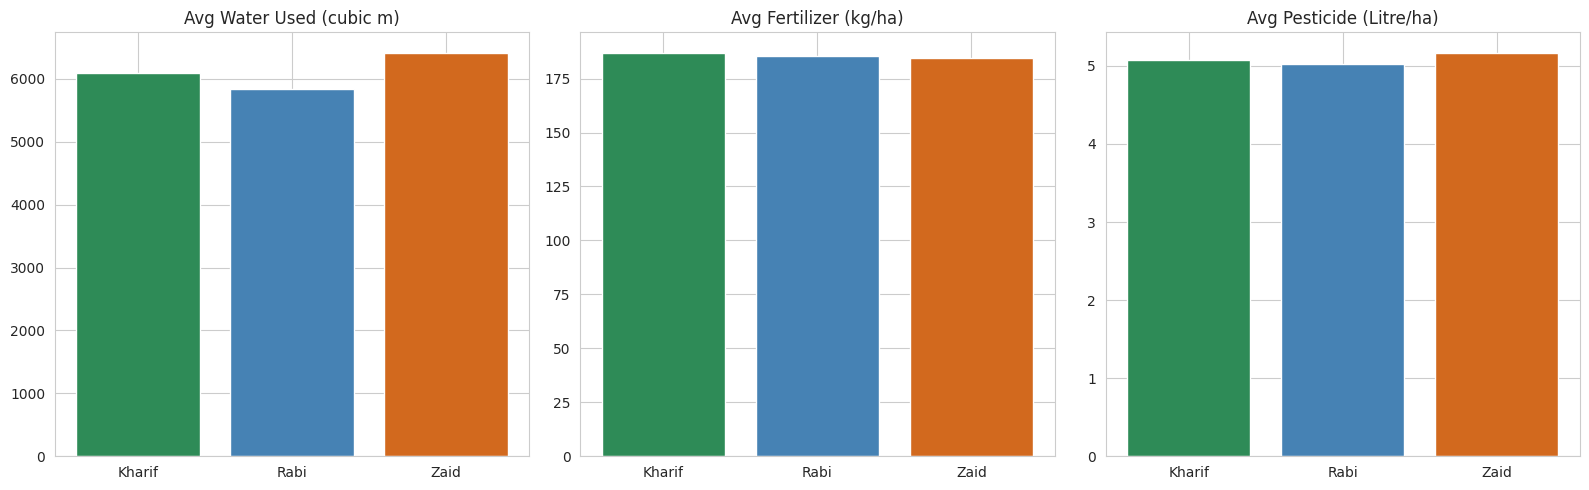

        Water_Used_m3  Fertilizer_kg_ha  Pesticide_Litre_ha
Season                                                     
Kharif        6102.20            187.08                5.08
Rabi          5846.99            185.41                5.02
Zaid          6419.89            184.64                5.17


In [18]:
res_vars = ['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']
res_means = df.groupby('Season')[res_vars].mean().reindex(SEASON_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Avg Water Used (cubic m)', 'Avg Fertilizer (kg/ha)', 'Avg Pesticide (Litre/ha)']

for i, (col, title) in enumerate(zip(res_vars, titles)):
    axes[i].bar(res_means.index, res_means[col], color=[SEASON_COLORS[s] for s in res_means.index])
    axes[i].set_title(title)

plt.tight_layout()
plt.show()
print(res_means.round(2))

## Section 18: Water Use Efficiency Across Seasons

`Water_Efficiency_t_per_1000m3` measures how much yield is produced per unit of water used. We compare this across seasons.

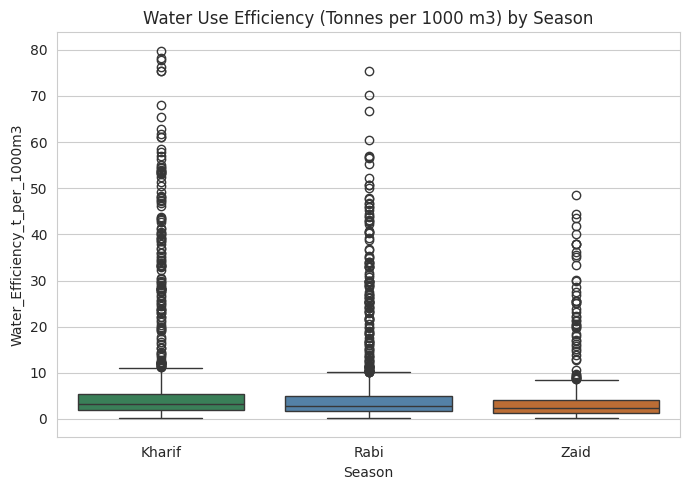

Season
Kharif    5.89
Rabi      5.19
Zaid      4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64


In [19]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER,
            hue='Season', palette=SEASON_COLORS, legend=False)
plt.title('Water Use Efficiency (Tonnes per 1000 m3) by Season')
plt.tight_layout()
plt.show()

print(df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().reindex(SEASON_ORDER).round(2))

**Observation:** Water use efficiency follows the same declining pattern as yield and profit: highest in Kharif (~5.89), moderate in Rabi (~5.19), and lowest in Zaid (~4.41). Farms are not just using more or less water across seasons — they are converting that water into crop output less effectively in Zaid.

## Section 19: Disease & Pest Risk Across Seasons

We compare the average disease and pest risk percentage across seasons.

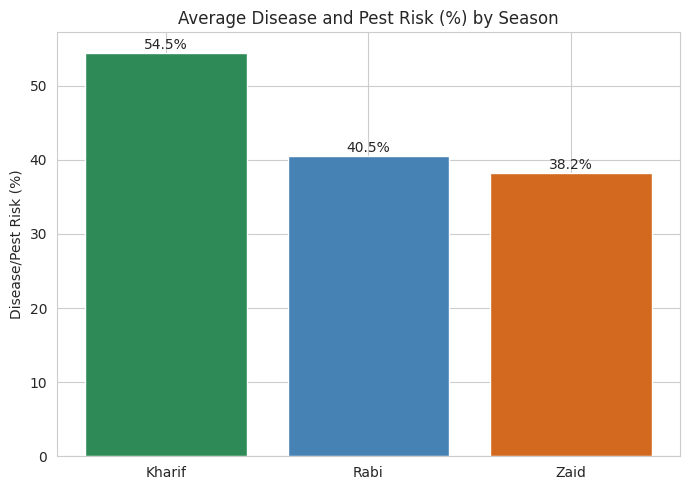

In [20]:
disease_means = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(SEASON_ORDER)

plt.figure(figsize=(7, 5))
plt.bar(disease_means.index, disease_means.values, color=[SEASON_COLORS[s] for s in disease_means.index])
plt.title('Average Disease and Pest Risk (%) by Season')
plt.ylabel('Disease/Pest Risk (%)')
for i, v in enumerate(disease_means.values):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

**Observation:** Disease and pest risk is highest in Kharif (~54%), likely linked to the higher rainfall and humidity, and lowest in Zaid (~38%), the driest season. This is a useful counterpoint to Kharif's otherwise strong performance — higher yields there come with higher crop-protection risk.

## Section 20: Crop-wise Yield Performance Across Seasons

We build a pivot table of average yield by `Crop` and `Season`, visualized as a heatmap, to see whether the seasonal yield pattern is consistent across every crop or differs by crop.

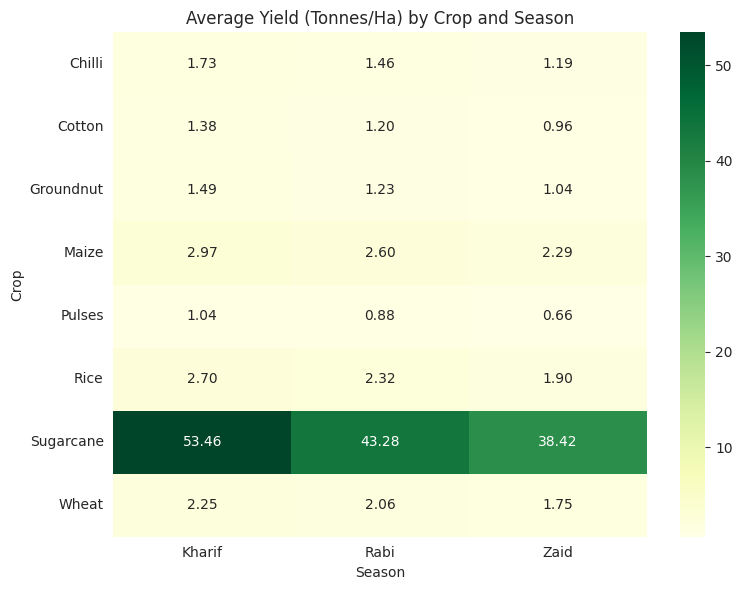

In [21]:
crop_season_yield = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha',
                                    aggfunc='mean').reindex(columns=SEASON_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_yield.round(2), annot=True, fmt='.2f', cmap='YlGn')
plt.title('Average Yield (Tonnes/Ha) by Crop and Season')
plt.tight_layout()
plt.show()

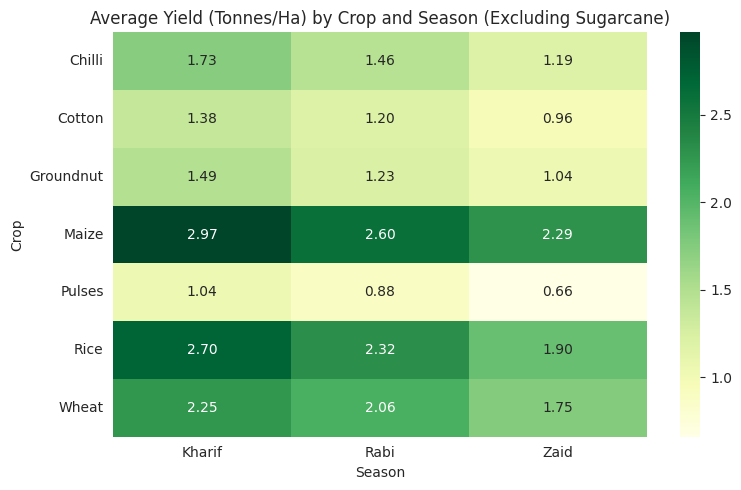

In [22]:
# Sugarcane's yield is measured in the same unit but is naturally far higher (biomass crop),
# which compresses the color scale for every other crop. We plot the remaining crops separately.
crop_season_yield_no_sugarcane = crop_season_yield.drop('Sugarcane')

plt.figure(figsize=(8, 5))
sns.heatmap(crop_season_yield_no_sugarcane.round(2), annot=True, fmt='.2f', cmap='YlGn')
plt.title('Average Yield (Tonnes/Ha) by Crop and Season (Excluding Sugarcane)')
plt.tight_layout()
plt.show()

**Observation:** The Kharif > Rabi > Zaid yield pattern holds consistently for **every single crop** in the dataset — this is a genuinely robust seasonal effect, not something driven by one or two crops. Separately, Sugarcane's average yield (~38–53 t/ha) is roughly 15–30x higher than every other crop, which is expected given it is a biomass crop, but it is worth excluding from combined-crop yield comparisons to avoid skewing the picture.

## Section 21: State-wise Seasonal Profit Patterns

We build a pivot table of average profit by `State` and `Season` to see whether the seasonal profit pattern is consistent across every region, or whether some states behave differently.

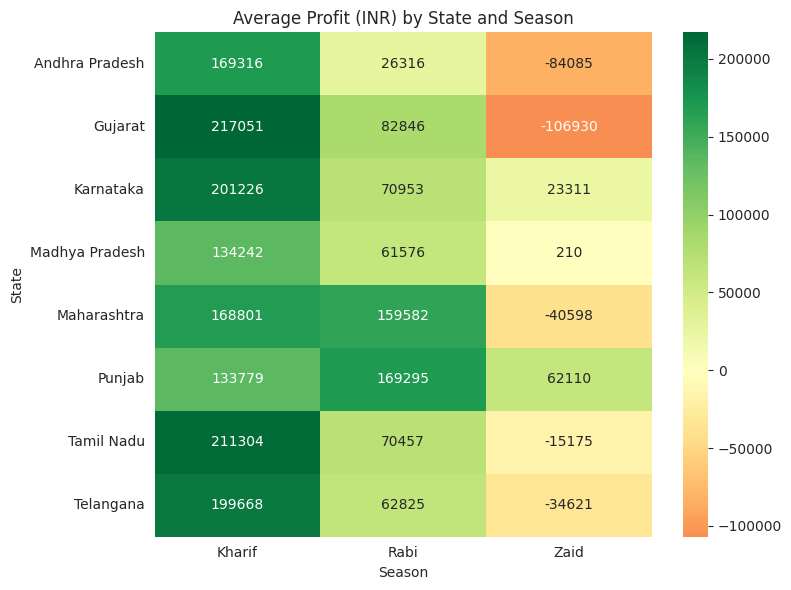

In [23]:
state_season_profit = df.pivot_table(index='State', columns='Season', values='Profit_INR',
                                      aggfunc='mean').reindex(columns=SEASON_ORDER)

plt.figure(figsize=(8, 6))
sns.heatmap(state_season_profit.round(0), annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by State and Season')
plt.tight_layout()
plt.show()

**Observation:** Six of the eight states swing to a negative average profit in Zaid. Punjab stands out as the only state with a **positive average profit in all three seasons**, including Zaid (~₹62,000), suggesting its farming conditions or practices are more resilient to the hot, dry summer season than the rest of the dataset.

## Section 22: Irrigation Method Effectiveness Across Seasons

We compare average yield by `Irrigation_Method` within each season to see which irrigation method performs best, and whether the best method changes from season to season.

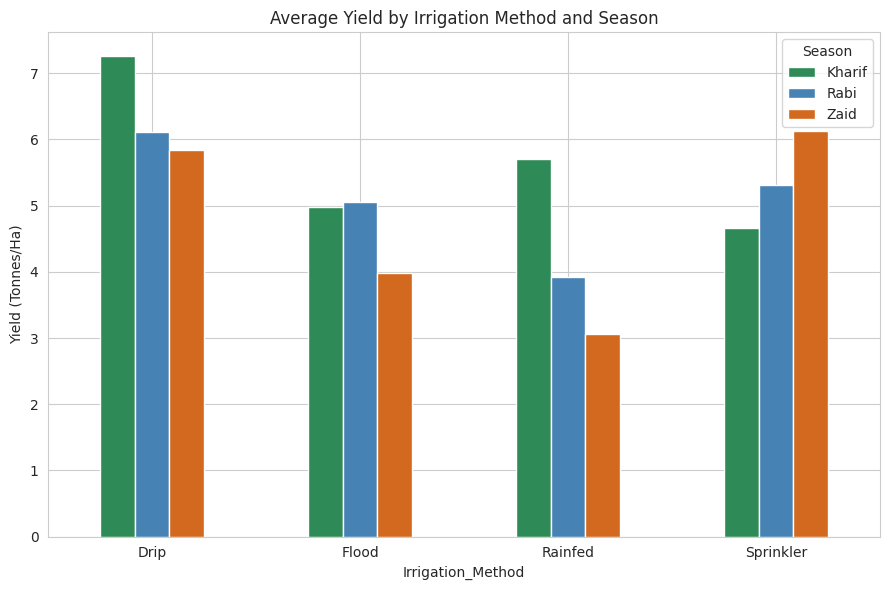

Season             Kharif  Rabi  Zaid
Irrigation_Method                    
Drip                 7.26  6.11  5.85
Flood                4.98  5.06  3.98
Rainfed              5.70  3.93  3.06
Sprinkler            4.66  5.31  6.13


In [24]:
irrigation_season_yield = df.pivot_table(index='Irrigation_Method', columns='Season',
                                          values='Yield_Tonnes_Ha', aggfunc='mean').reindex(columns=SEASON_ORDER)

irrigation_season_yield.plot(kind='bar', figsize=(9, 6),
                              color=[SEASON_COLORS[s] for s in SEASON_ORDER])
plt.title('Average Yield by Irrigation Method and Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

print(irrigation_season_yield.round(2))

**Observation:** Drip irrigation gives the highest yield in both Kharif (7.26 t/ha) and Rabi (6.21 t/ha), but in Zaid, Sprinkler irrigation takes the lead (6.17 t/ha vs. Drip's 5.85 t/ha). Rainfed farming is consistently the weakest method in Rabi and Zaid, which makes sense given those seasons receive far less natural rainfall.

## Section 23: Correlation Analysis

We compute the correlation between all numeric variables to identify which factors are most strongly related to yield and profit.

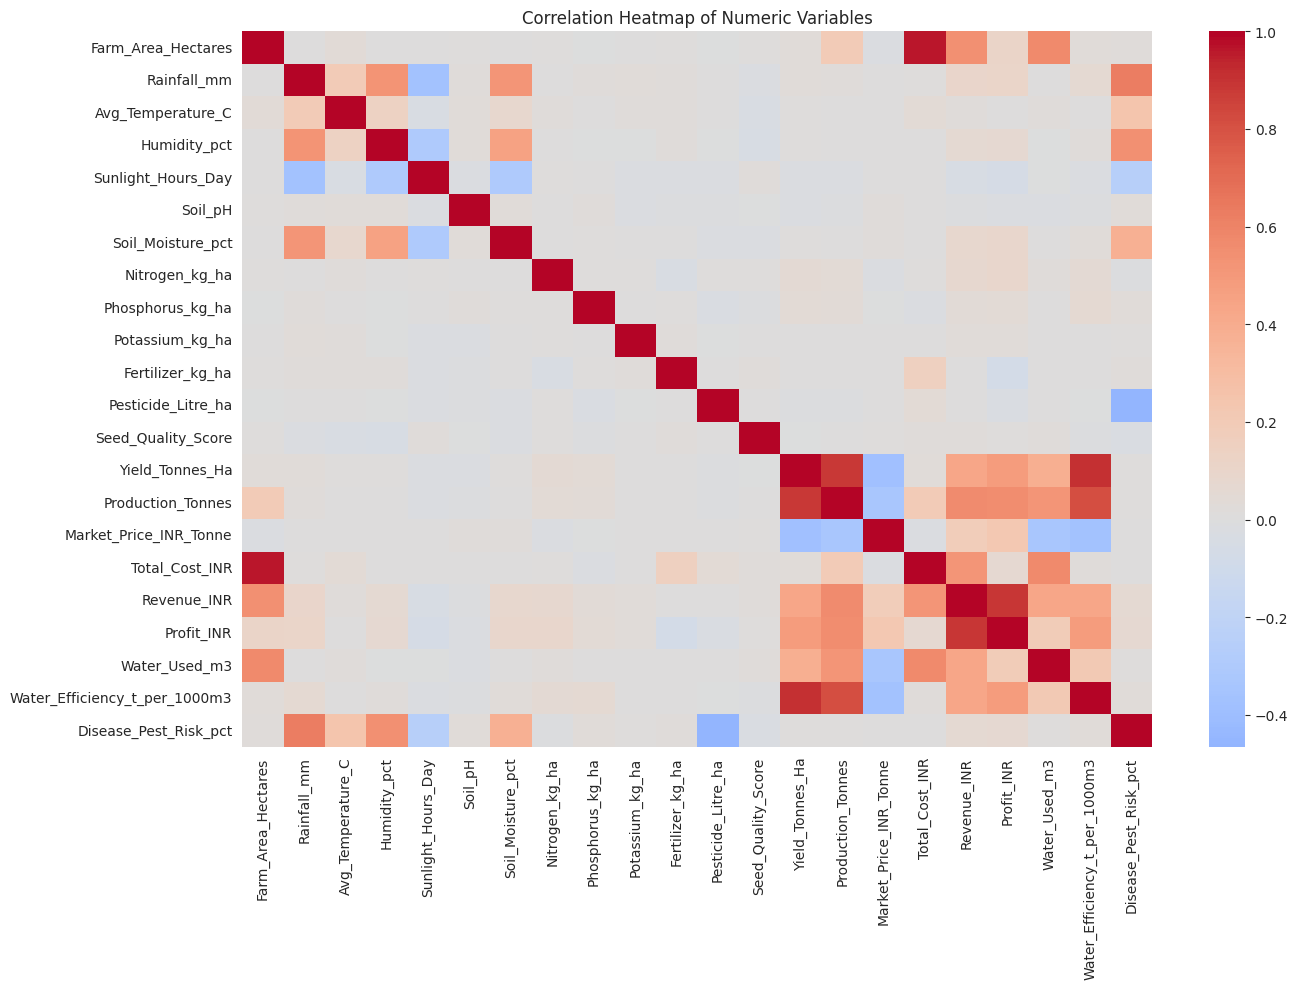

Top correlations with Yield_Tonnes_Ha:
Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912561
Production_Tonnes                0.882804
Profit_INR                       0.488459
Revenue_INR                      0.432139
Water_Used_m3                    0.386298
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Profit_INR                       1.000000
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488459
Market_Price_INR_Tonne           0.225119
Name: Profit_INR, dtype: float64


In [25]:
numeric_df = df.select_dtypes(include='number').drop(columns=['Is_Loss'], errors='ignore')
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

print("Top correlations with Yield_Tonnes_Ha:")
print(corr['Yield_Tonnes_Ha'].sort_values(ascending=False).head(6))
print("\nTop correlations with Profit_INR:")
print(corr['Profit_INR'].sort_values(ascending=False).head(6))

**Observation:** `Water_Efficiency_t_per_1000m3` has by far the strongest correlation with yield (~0.92) — much stronger than any environmental variable like rainfall or temperature. This suggests that **how efficiently water is used** matters more for yield outcomes than raw environmental conditions or input quantities alone. `Market_Price_INR_Tonne` is moderately *negatively* correlated with yield (~-0.38), hinting that high-yield crops in this dataset tend to sell at lower per-tonne prices (e.g. grain crops vs. cash crops).

## Section 24: Relationship Between Rainfall and Yield

A scatter plot of rainfall against yield, colored by season, lets us see whether the seasonal grouping itself explains more of the pattern than rainfall alone.

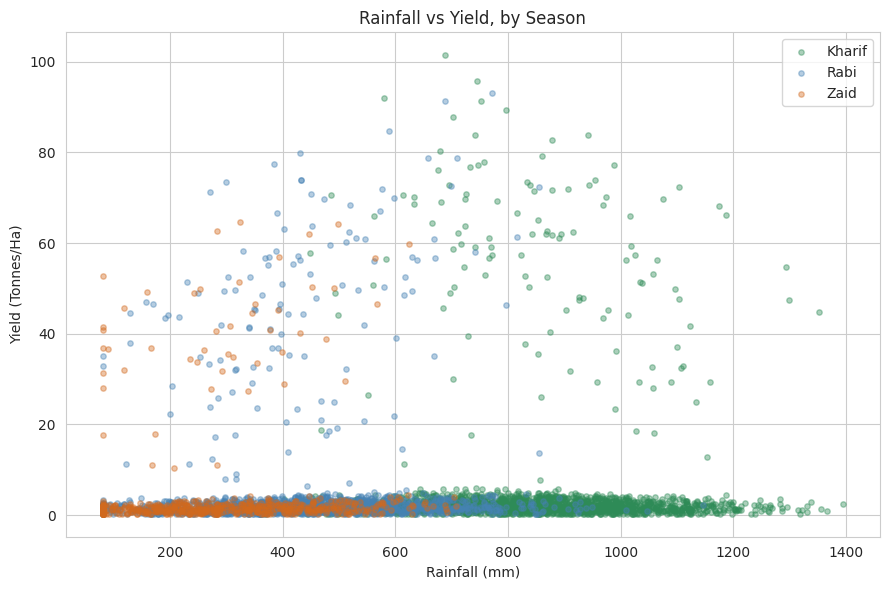

In [26]:
plt.figure(figsize=(9, 6))
for season in SEASON_ORDER:
    subset = df[df['Season'] == season]
    plt.scatter(subset['Rainfall_mm'], subset['Yield_Tonnes_Ha'], alpha=0.4,
                label=season, color=SEASON_COLORS[season], s=15)
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.title('Rainfall vs Yield, by Season')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Within any single season, yield does not rise clearly with rainfall — the points are scattered fairly evenly. The main pattern visible here is the seasonal clustering itself (Kharif's high-rainfall points sit at generally higher yields), rather than a direct rainfall-yield relationship within a season. This matches the very low overall correlation between rainfall and yield seen in Section 23.

## Section 25: Relationship Between Water Efficiency and Profit

Since water efficiency showed the strongest correlation with yield, we check its relationship with profit as well.

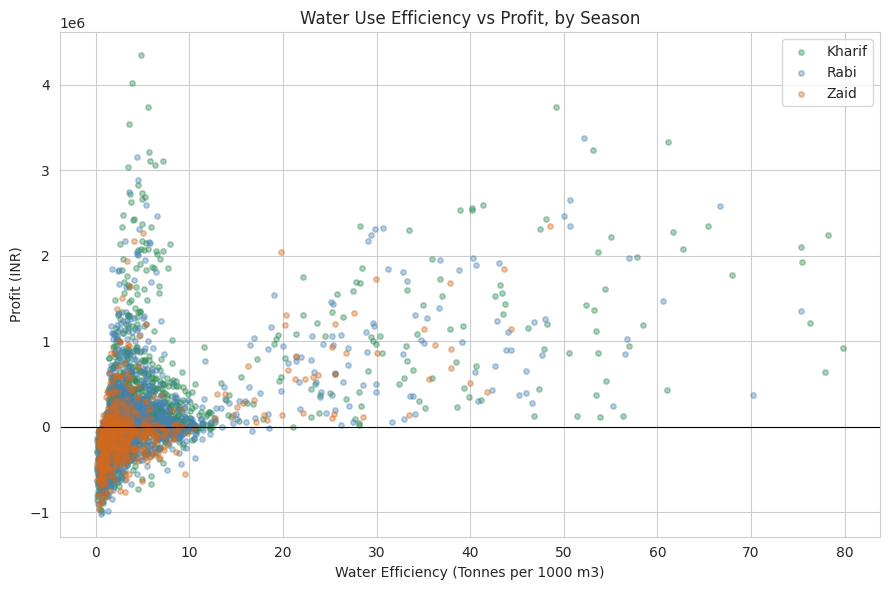

In [27]:
plt.figure(figsize=(9, 6))
for season in SEASON_ORDER:
    subset = df[df['Season'] == season]
    plt.scatter(subset['Water_Efficiency_t_per_1000m3'], subset['Profit_INR'], alpha=0.4,
                label=season, color=SEASON_COLORS[season], s=15)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Water Efficiency (Tonnes per 1000 m3)')
plt.ylabel('Profit (INR)')
plt.title('Water Use Efficiency vs Profit, by Season')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Farms with very low water efficiency are almost always clustered near or below the zero-profit line (black line), across all three seasons. This reinforces water efficiency as a key lever connected to farm profitability, not just yield.

## Section 26: Outlier Detection

We use the IQR (Interquartile Range) method to detect outliers in `Yield_Tonnes_Ha` and `Profit_INR`, and visualize them with boxplots.

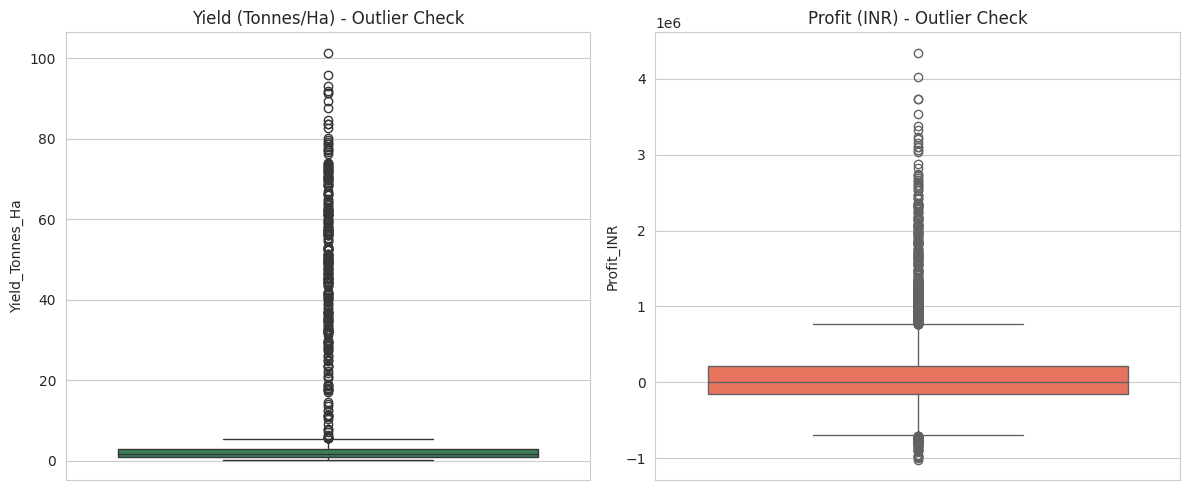

Outliers detected in Yield_Tonnes_Ha (IQR method): 302
Outliers detected in Profit_INR (IQR method): 404


In [28]:
def iqr_outlier_count(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=axes[0], color='seagreen')
axes[0].set_title('Yield (Tonnes/Ha) - Outlier Check')
sns.boxplot(y=df['Profit_INR'], ax=axes[1], color='tomato')
axes[1].set_title('Profit (INR) - Outlier Check')
plt.tight_layout()
plt.show()

print(f"Outliers detected in Yield_Tonnes_Ha (IQR method): {iqr_outlier_count(df['Yield_Tonnes_Ha'])}")
print(f"Outliers detected in Profit_INR (IQR method): {iqr_outlier_count(df['Profit_INR'])}")

**Observation:** Most yield outliers are Sugarcane records — a genuine characteristic of that crop rather than a data error, so we retain them. Profit outliers include a number of extreme-loss farms; these are flagged here as **areas requiring further investigation** rather than removed, since dropping them could hide real risk cases that matter for planning.

## Section 27: Top and Bottom Performing Farms

Finally, we look at the individual farms with the highest and lowest profit, to ground the aggregate patterns above in concrete examples.

In [29]:
print("Top 10 Most Profitable Farms:")
display(df.sort_values('Profit_INR', ascending=False)
        [['Farm_ID', 'State', 'Crop', 'Season', 'Yield_Tonnes_Ha', 'Profit_INR']].head(10))

print("\nBottom 10 Least Profitable Farms:")
display(df.sort_values('Profit_INR', ascending=True)
        [['Farm_ID', 'State', 'Crop', 'Season', 'Yield_Tonnes_Ha', 'Profit_INR']].head(10))

Top 10 Most Profitable Farms:


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Profit_INR
2236,SF12237,Punjab,Chilli,Kharif,3.90,4345421
626,SF10627,Maharashtra,Chilli,Kharif,2.92,4021850
3425,SF13426,Madhya Pradesh,Sugarcane,Kharif,82.68,3740099
1690,SF11691,Karnataka,Chilli,Kharif,3.01,3738329
247,SF10248,Maharashtra,Chilli,Kharif,3.09,3542204
357,SF10358,Punjab,Sugarcane,Rabi,84.75,3378879
3423,SF13424,Andhra Pradesh,Sugarcane,Kharif,95.79,3330582
1930,SF11931,Tamil Nadu,Sugarcane,Kharif,79.25,3232970
3983,SF13984,Gujarat,Chilli,Kharif,3.02,3211345
263,SF10264,Maharashtra,Chilli,Rabi,2.53,3159447



Bottom 10 Least Profitable Farms:


,Farm_ID,State,Crop,Season,Yield_Tonnes_Ha,Profit_INR
780,SF10781,Andhra Pradesh,Groundnut,Rabi,0.30,-1019223
2210,SF12211,Andhra Pradesh,Wheat,Rabi,0.30,-995195
3625,SF13626,Punjab,Maize,Rabi,0.97,-981050
2182,SF12183,Andhra Pradesh,Rice,Kharif,1.01,-976860
104,SF10105,Gujarat,Wheat,Zaid,0.30,-965197
3394,SF13395,Gujarat,Wheat,Kharif,0.30,-963396
2730,SF12731,Madhya Pradesh,Rice,Rabi,1.66,-906082
1311,SF11312,Punjab,Rice,Zaid,0.45,-902740
585,SF10586,Telangana,Cotton,Zaid,0.30,-895730
3090,SF13091,Karnataka,Maize,Kharif,0.41,-890641


## Section 28: Key Insights & Findings

- **Kharif is the strongest season overall**: highest average rainfall (~852 mm), highest average yield (~5.64 t/ha), highest average profit (~₹1.79 lakh), and the lowest share of loss-making farms (~42%).
- **Zaid is the weakest and riskiest season**: lowest rainfall (~299 mm) and humidity, lowest average yield (~4.67 t/ha), and it is the *only* season with a **negative average profit** (~-₹25,000). About 64% of Zaid farm records operate at a loss.
- **Roughly half of all farms (~49%) operate at a loss overall**, and this share rises steadily from Kharif → Rabi → Zaid — a clear and consistent seasonal risk pattern.
- **The Kharif > Rabi > Zaid yield ordering holds for every single crop**, meaning this is a genuine seasonal effect, not one driven by a particular crop.
- **Water use efficiency is the strongest driver of yield** (correlation ≈ 0.92) — far stronger than rainfall, temperature, or fertilizer use. Yield and profit both track water efficiency more closely than raw environmental conditions.
- **Disease and pest risk is highest in Kharif** (~54%) and lowest in Zaid (~38%), so Kharif's strong yield and profit performance comes bundled with higher crop-protection risk.
- **The best irrigation method depends on the season**: Drip irrigation performs best in Kharif and Rabi, but Sprinkler irrigation edges ahead in Zaid — a pattern that would be missed by looking at irrigation methods in aggregate.
- **State-level resilience varies**: most states swing to a loss in Zaid, but Punjab maintains a positive average profit in all three seasons, making it a useful reference case.
- **Sugarcane is a major outlier by design** (yield 15–30x higher than other crops) and should be analyzed separately from grain/other crops rather than combined into a single yield metric.


## Section 29: Recommendations

1. **Prioritize Zaid-season support programs** — subsidies, crop insurance, or price support — since this season shows a systemic net loss across most states, not just isolated cases.
2. **Promote water-efficient irrigation more widely**, since water efficiency is the strongest measured driver of both yield and profit. Given the seasonal switch in best-performing method, irrigation guidance should be season-specific (Drip for Kharif/Rabi, Sprinkler for Zaid) rather than one-size-fits-all.
3. **Strengthen disease and pest management specifically during Kharif**, when risk is highest, to help convert Kharif's strong yield potential into equally strong realized profit.
4. **Study Punjab's Zaid-season practices** as a potential model, since it is the only state that stays profitable across all three seasons.
5. **Analyze high-value/cash crops (e.g., Sugarcane) separately** from grain crops in future reporting, since combining them distorts aggregate yield metrics and can mask patterns in the majority of crops.
6. **Investigate the extreme-loss outlier farms** identified in the outlier detection and bottom-performer sections individually, as they may point to specific input, pricing, or regional issues worth addressing directly.


## Summary of Tasks Completed

- [x] Loaded the seasonal agriculture performance dataset
- [x] Explored the dataset using head, tail, shape, columns, data types, and `info()`
- [x] Generated statistical summaries for numeric and categorical columns
- [x] Checked for missing values and visualized them
- [x] Checked for duplicate records and verified ID uniqueness
- [x] Cleaned the data by imputing missing values using season-wise medians
- [x] Verified the dataset was fully cleaned (zero remaining nulls)
- [x] Explored categorical variables (State, District, Crop, Season, Irrigation Method)
- [x] Analyzed the distribution of records across seasons
- [x] Performed univariate analysis on key numeric variables (histograms)
- [x] Compared environmental conditions (rainfall, temperature, humidity) across seasons
- [x] Compared crop yield across seasons
- [x] Compared economic performance (cost, revenue, profit) across seasons
- [x] Quantified the percentage of loss-making farms by season
- [x] Compared resource usage (water, fertilizer, pesticide) across seasons
- [x] Compared water use efficiency across seasons
- [x] Compared disease and pest risk across seasons
- [x] Built a crop × season yield heatmap to check consistency across crops
- [x] Built a state × season profit heatmap to check consistency across regions
- [x] Compared irrigation method effectiveness across seasons
- [x] Performed correlation analysis across all numeric variables
- [x] Explored the relationship between rainfall and yield
- [x] Explored the relationship between water efficiency and profit
- [x] Detected outliers in yield and profit using the IQR method
- [x] Identified top and bottom performing farms by profit
- [x] Documented key insights and findings based on the evidence
- [x] Provided data-driven recommendations for seasonal agricultural planning
